In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [5]:
def adder(state: AgentState) -> AgentState:
    """This nodes add the two numbers"""

    state['finalNumber'] = state['number1'] + state['number2']

    return state


def subtractor(state: AgentState) -> AgentState:
    """This nodes subtracts the two numbers"""

    state['finalNumber'] = state['number1'] - state['number2']

    return state


def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation'] == "+":
        return "addition_operation" # Edge Name

    elif state['operation'] == "-":
        return "subtraction_operation" # Edge Name

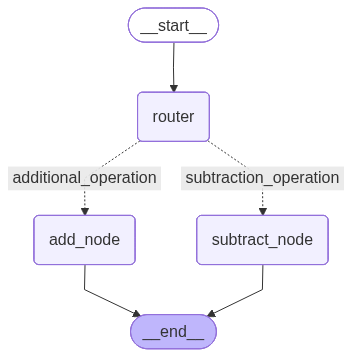

In [8]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state) # Passthrough Function

graph.add_edge(START, "router") 
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "additional_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

app

In [10]:
initial_state_1 = AgentState(number1=10, operation="-", number2=5)

app.invoke(initial_state_1)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}